<a href="https://colab.research.google.com/github/Mohammed-Abdul-Rafe-Sajid/Deep-Learning-/blob/main/LAB_4_Regularizers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ✅ Experiment: Comparing Neural Network Regularization Techniques (MNIST)

## 📌 Objective

To compare the performance of a neural network classification model using different regularization techniques and evaluate their effect on:

- Model Accuracy  
- Training Loss  
- Validation Loss  
- Generalization Ability  
- Overfitting Reduction  

---

## 🧠 Dataset: MNIST

### 🔹 About MNIST

- 70,000 grayscale images  
- Image size: 28 × 28  
- 10 classes (digits 0–9)  

---

## 🧾 Data Preprocessing

- Flatten images (28×28 → 784)  
- Normalize pixel values (0–255 → 0–1)  
- One-hot encode labels  

---

## 🔒 Regularization Techniques Used

### 1️⃣ L1 Regularization
- Adds penalty: |weights|  
- Produces sparse weights  
- Can eliminate less important features  

### 2️⃣ L2 Regularization
- Adds penalty: weights²  
- Prevents large weights  
- Most commonly used  

### 3️⃣ ElasticNet (L1 + L2)
- Combines L1 and L2  
- Balanced regularization  

### 4️⃣ Dropout
- Randomly drops neurons during training  
- Reduces overfitting  

### 5️⃣ Early Stopping
- Stops training when validation loss stops improving  
- Prevents unnecessary epochs  

---

## 📊 Evaluation Metrics

- Training Loss  
- Validation Loss  
- Test Accuracy  

---

## 📈 Expected Observations

| Technique | Overfitting | Accuracy | Generalization |
|------------|------------|----------|----------------|
| No Regularization | High | High train / Low val | Poor |
| L1 | Medium | Moderate | Better |
| L2 | Low | High | Very Good |
| ElasticNet | Very Low | High | Excellent |
| Dropout + EarlyStopping | Very Low | High | Best |

---

## 🧪 Experiment Procedure

- Load MNIST dataset  
- Preprocess data  
- Train 4 models:
  - L1 Regularization  
  - L2 Regularization  
  - ElasticNet Regularization  
  - Dropout + Early Stopping  
- Compare accuracy and loss  
- Visualize results  


Test Accuracy Comparison:
L1: 0.8936
L2: 0.9552
ElasticNet: 0.8719
Dropout+EarlyStop: 0.9764


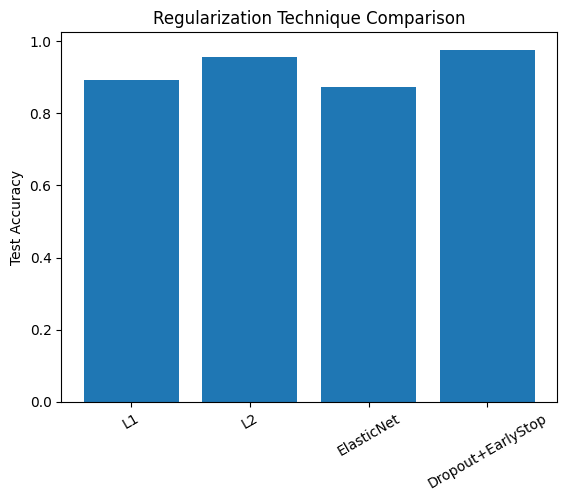

In [2]:
# ==========================================
# MNIST Regularization Comparison Experiment
# ==========================================

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import matplotlib.pyplot as plt

# Load MNIST
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# Preprocess
X_train = X_train.reshape(-1, 784).astype('float32') / 255.0
X_test = X_test.reshape(-1, 784).astype('float32') / 255.0

num_classes = 10
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

results = {}

# Function to build model
def build_model(reg_type=None):
    model = keras.Sequential()

    if reg_type == "l1":
        reg = regularizers.l1(0.01)
    elif reg_type == "l2":
        reg = regularizers.l2(0.01)
    elif reg_type == "elastic":
        reg = regularizers.l1_l2(l1=0.01, l2=0.01)
    else:
        reg = None

    model.add(layers.Dense(128, activation='relu', input_shape=(784,), kernel_regularizer=reg))
    model.add(layers.Dense(64, activation='relu', kernel_regularizer=reg))
    model.add(layers.Dense(10, activation='softmax'))

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model

# ==============================
# L1 Regularization
# ==============================
model_l1 = build_model("l1")
history_l1 = model_l1.fit(X_train, y_train, validation_split=0.2,
                          epochs=20, batch_size=32, verbose=0)
results["L1"] = model_l1.evaluate(X_test, y_test, verbose=0)[1]

# ==============================
# L2 Regularization
# ==============================
model_l2 = build_model("l2")
history_l2 = model_l2.fit(X_train, y_train, validation_split=0.2,
                          epochs=20, batch_size=32, verbose=0)
results["L2"] = model_l2.evaluate(X_test, y_test, verbose=0)[1]

# ==============================
# ElasticNet Regularization
# ==============================
model_elastic = build_model("elastic")
history_elastic = model_elastic.fit(X_train, y_train, validation_split=0.2,
                                    epochs=20, batch_size=32, verbose=0)
results["ElasticNet"] = model_elastic.evaluate(X_test, y_test, verbose=0)[1]

# ==============================
# Dropout + Early Stopping
# ==============================
model_dropout = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(784,)),
    layers.Dropout(0.4),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

model_dropout.compile(optimizer='adam',
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_dropout = model_dropout.fit(X_train, y_train,
                                    validation_split=0.2,
                                    epochs=100,
                                    batch_size=32,
                                    callbacks=[early_stop],
                                    verbose=0)

results["Dropout+EarlyStop"] = model_dropout.evaluate(X_test, y_test, verbose=0)[1]

# ==============================
# Print Results
# ==============================
print("\nTest Accuracy Comparison:")
for k, v in results.items():
    print(f"{k}: {v:.4f}")

# ==============================
# Bar Plot Comparison
# ==============================
plt.figure()
plt.bar(results.keys(), results.values())
plt.title("Regularization Technique Comparison")
plt.ylabel("Test Accuracy")
plt.xticks(rotation=30)
plt.show()